In [52]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



# start with some U_true and make it arrange.logpi

In [53]:
height = 30
width = 30
K_main = 5
K_subparcels = 5
K_total = 25

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=25, P=grid.P)
# centroids = [(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [54]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [55]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

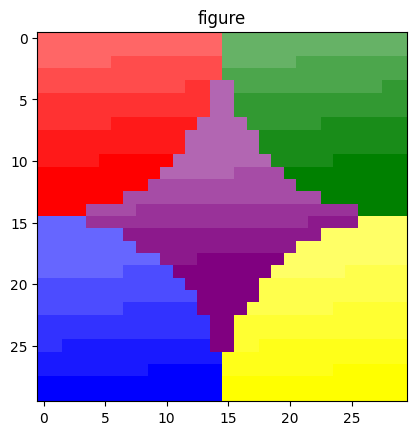

In [56]:
U_true_25 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_25 = pt.tensor(U_true_25, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true_25)

plot_Us(U_true_25)

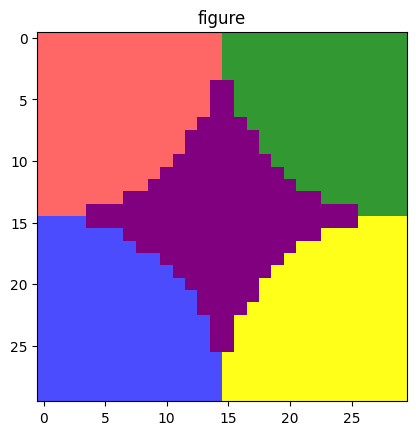

In [57]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, 1)
plot_Us(U_true_5)
U_true_5 = U_true_5[np.newaxis, :, :]

# Make Vs based on a task covariance + parcel covariance

Covarince across parcels R

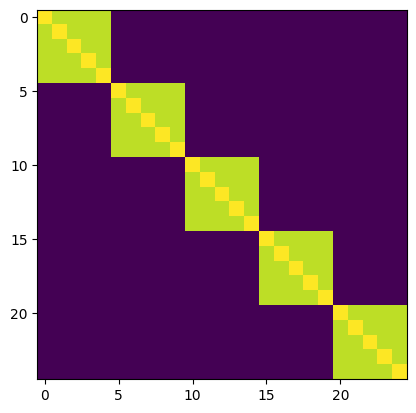

In [183]:
R= sim.custom_R(K_total =25, group_size=5, base_parcel_correlation=0.5, sub_parcel_extra_correlation=0.45)
plt.imshow(R)


covariance across tasks G

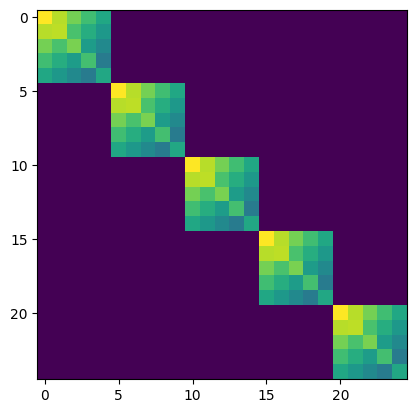

In [184]:
variance_factors = [[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6]]
G = sim.custom_G(n_tasks=25, n_groups=5, group_size=5, target_corr=0.99, variance_factors=variance_factors)
plt.imshow(G)

make Vs (this num_iter gives a good V)

17.613652168263002
15.202629408012863
15.171034613279941
14.651788280270802
14.550428466507402
14.271245668305681
14.268131317850955
14.194719035643718


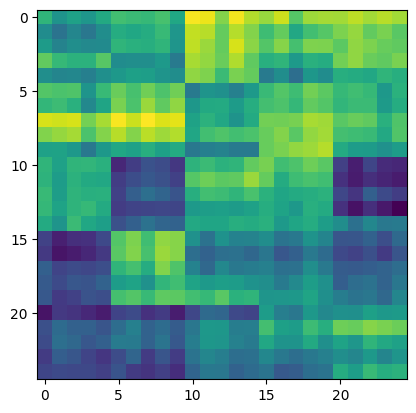

In [185]:
Vs_25= sim.find_best_V(G=G,R=R,num_iter=16000,rng = np.random.default_rng(101))
plt.imshow(Vs_25)


check covariance across rows and columns

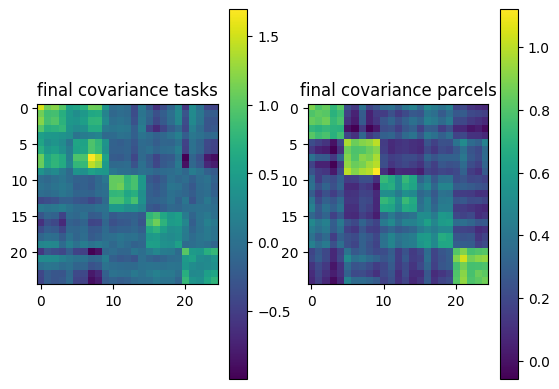

In [186]:
plt.subplot(1, 2, 1)
plt.imshow(Vs_25 @ Vs_25.T, cmap='viridis')
plt.colorbar()
plt.title('final covariance tasks')

plt.subplot(1, 2, 2)
plt.imshow(Vs_25.T @ Vs_25, cmap='viridis')
plt.colorbar()
plt.title('final covariance parcels')
plt.show()


lower dimensional Vs (just for the 5 main parcels)

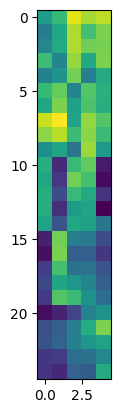

In [187]:
Vs_5 = Vs_25.reshape(25, 5, 5).mean(axis=2)
plt.imshow(Vs_5)

make true data

In [188]:
Y_true = Vs_25 @ np.array(U_true_25)


G matrix used for eigenmetrics

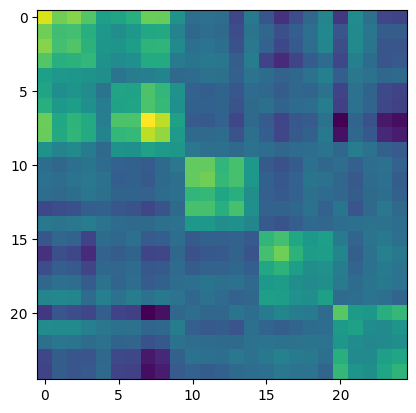

In [189]:
G_lib = Y_true @ Y_true.T
G_lib = np.array(G_lib)
plt.imshow(G_lib)

# Build combination dataframe

In [190]:
noise =0.15
vtest = Vs_5
ytest = Y_true + np.random.normal(0, noise, Y_true.shape)

In [191]:
D = ut.build_combinations(G_lib, strategy='balanced',n_iter=10000,n_tasks=8,seed=605,balanced_sampling_unique=[2,3,4,5,6,7,8])
D_ev = ev.evaluate_dataframe_simulation_multiregion(D,Y_true, Vs_5, U_true_5,sig_e=noise,vtest=vtest,ytest=ytest)
display(D['n_unique'].value_counts())
n_min = D['n_unique'].value_counts().min()

building0
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing combination: 4000
Processing combination: 5000
Processing combination: 6000
Processing combination: 7000
Processing combination: 8000
Processing combination: 9000


n_unique
6    1428
7    1428
8    1427
5    1427
4    1423
3    1384
2     891
Name: count, dtype: int64

# Build model

<Axes: xlabel='n_unique', ylabel='Value'>

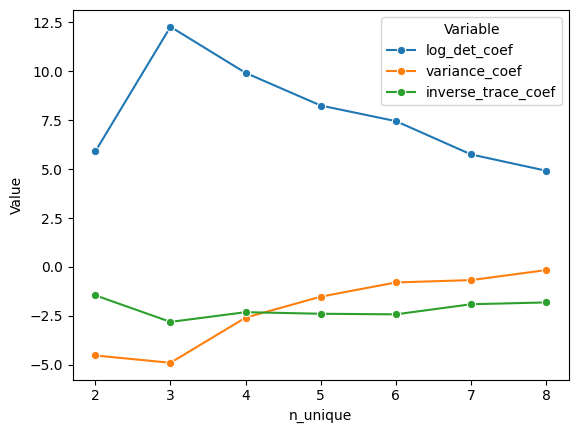

In [193]:
results_df = ut.run_regression_for_unique(df=D_ev,x_variables=['log_det','variance','inverse_trace'],y_variable='perc',n=n_min-1,random_state=0)
df_melted = results_df.melt(
    id_vars=["n_unique"], 
    value_vars=[col for col in results_df.columns if col.endswith('_coef')],  
    var_name="Variable",
    value_name="Value"  
)
sns.lineplot(data=df_melted, x="n_unique", y="Value", hue="Variable", marker="o")


(-0.12, 0.12)

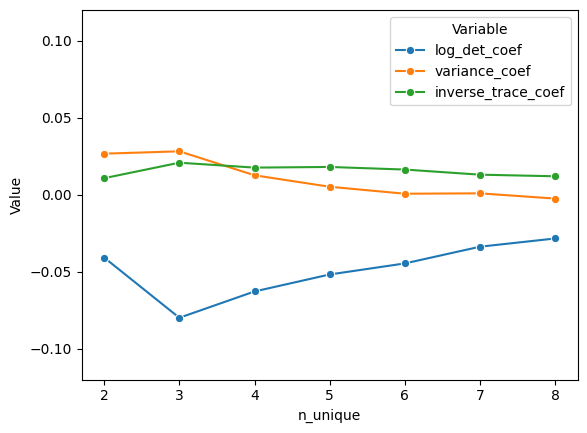

In [194]:
results_df = ut.run_regression_for_unique(df=D_ev,x_variables=['log_det','variance','inverse_trace'],y_variable='cos',n=n_min-1,random_state=0)
df_melted = results_df.melt(
    id_vars=["n_unique"], 
    value_vars=[col for col in results_df.columns if col.endswith('_coef')],  
    var_name="Variable",
    value_name="Value"  
)
sns.lineplot(data=df_melted, x="n_unique", y="Value", hue="Variable", marker="o")
plt.ylim(-0.12,0.12)

(-0.12, 0.12)

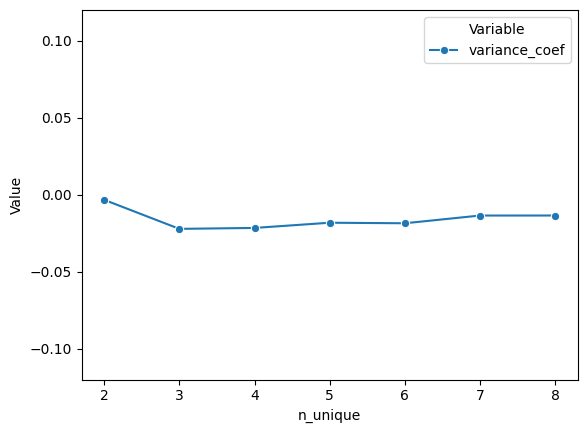

In [195]:
results_df = ut.run_regression_for_unique(df=D_ev,x_variables=['variance'],y_variable='cos',n=n_min-1,random_state=0)
df_melted = results_df.melt(
    id_vars=["n_unique"], 
    value_vars=[col for col in results_df.columns if col.endswith('_coef')],  
    var_name="Variable",
    value_name="Value"  
)
sns.lineplot(data=df_melted, x="n_unique", y="Value", hue="Variable", marker="o")
plt.ylim(-0.12,0.12)

(-0.12, 0.12)

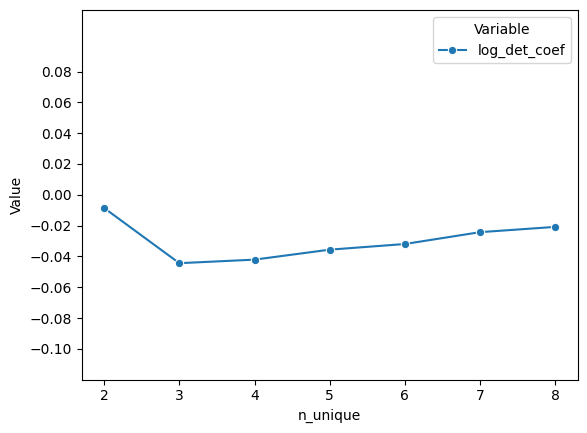

In [196]:
results_df = ut.run_regression_for_unique(df=D_ev,x_variables=['log_det'],y_variable='cos',n=n_min-1,random_state=0)
df_melted = results_df.melt(
    id_vars=["n_unique"], 
    value_vars=[col for col in results_df.columns if col.endswith('_coef')],  
    var_name="Variable",
    value_name="Value"  
)
sns.lineplot(data=df_melted, x="n_unique", y="Value", hue="Variable", marker="o")
plt.yticks(np.arange(-0.1, 0.1, 0.02))
plt.ylim(-0.12,0.12)